# 1. Setup and Libraries

In [1]:
import os
import glob
import json
import numpy as np
import cv2
# import mediapipe as mp
import pandas as pd
import concurrent.futures
from scipy.spatial.transform import Rotation
from pathlib import Path
from tqdm import tqdm
import math
import time
import h5py
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# 2. Dataset Directories

In [2]:
dataset_Folder = "/kaggle/input/datasets/mohamdhussein/raw-to-mediapipe-3d/"
file_path = dataset_Folder + 'fit3d_info.json'

# 3. Load FIT3D Metadata

In [3]:
info_JSON = pd.read_json(file_path, typ='series')
print("JSON loaded successfully as a series:")
print(info_JSON.head())

val_subj_names = ['s03', 's11']
all_train = [sub for sub in info_JSON['train_subj_names'] if sub not in val_subj_names]
all_camera_names = info_JSON['all_camera_names']

# Extract all actions from all subjects and find unique values
all_actions_list = [action for actions in info_JSON['subj_to_act'].values() for action in actions]
unique_actions = sorted(list(set(all_actions_list)))

print(f"Number of unique actions: {len(unique_actions)}")
print("Unique actions:")
print(unique_actions)

JSON loaded successfully as a series:
subj_to_act         {'s03': ['band_pull_apart', 'dumbbell_high_pul...
test_subj_names                                       [s02, s12, s13]
train_subj_names             [s03, s04, s05, s07, s08, s09, s10, s11]
all_camera_names             [50591643, 58860488, 60457274, 65906101]
dtype: object
Number of unique actions: 47
Unique actions:
['band_pull_apart', 'barbell_dead_row', 'barbell_row', 'barbell_shrug', 'burpees', 'clean_and_press', 'deadlift', 'diamond_pushup', 'drag_curl', 'dumbbell_biceps_curls', 'dumbbell_curl_trifecta', 'dumbbell_hammer_curls', 'dumbbell_high_pulls', 'dumbbell_overhead_shoulder_press', 'dumbbell_reverse_lunge', 'dumbbell_scaptions', 'man_maker', 'mule_kick', 'neutral_overhead_shoulder_press', 'one_arm_row', 'overhead_extension_thruster', 'overhead_trap_raises', 'pushup', 'side_lateral_raise', 'squat', 'standing_ab_twists', 'w_raise', 'walk_the_box', 'warmup_1', 'warmup_10', 'warmup_11', 'warmup_12', 'warmup_13', 'warmup_14

# 4. Raw MediaPipe 3D Data Extraction (HDF5)
Extract raw `pose_world_landmarks` (N, 33, 3) tracking the labels. Saving to `Data/data_medipipe_3d`.

In [4]:
output_dir = Path("D:/GP/Pose/Dataset_medipipe_3d")
output_dir.mkdir(parents=True, exist_ok=True)

def process_video_raw_mediapipe(task):
    subj, action, cam_id, video_path, gt_3d = task['subj'], task['action'], task['cam_id'], task['video_path'], task['gt_3d']
    
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return None
        
    pred_3d_list = []
    mp_pose = mp.solutions.pose
    last_pose = np.zeros((33, 3))
    
    with mp_pose.Pose(min_detection_confidence=0.5, min_tracking_confidence=0.5, model_complexity=1, static_image_mode=False) as pose:
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret: break
            
            image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            image.flags.writeable = False
            results = pose.process(image)
            
            if results and getattr(results, 'pose_world_landmarks', None):
                current_pose = np.array([[lm.x, lm.y, lm.z] for lm in results.pose_world_landmarks.landmark])
            else:
                current_pose = last_pose
                
            pred_3d_list.append(current_pose)
            last_pose = current_pose
            
    cap.release()
    
    if len(pred_3d_list) == 0:
        return None
        
    return {
        'subj': subj,
        'action': action,
        'cam_id': cam_id,
        'pred_3d': np.array(pred_3d_list), # Shape (N, 33, 3)
        'gt_3d': gt_3d # Shape (N_gt, 25, 3)
    }

def get_all_tasks(dataset_base, all_train, val_subj_names, all_camera_names):
    # Combine all training and validation subjects for extraction
    all_subjs = list(all_train) + list(val_subj_names)
    tasks = []
    base_path = Path(dataset_base)
    
    for subj in all_subjs:
        ref_dir = base_path / "train" / subj / "joints3d_25"
        if not ref_dir.exists(): continue
        
        for ref_file in ref_dir.glob("*.json"):
            action = ref_file.stem
            gt_3d = None
            
            for cam_id in all_camera_names:
                v_path = base_path / "train" / subj / "videos" / str(cam_id) / f"{action}.mp4"
                if v_path.exists():
                    if gt_3d is None:
                        with open(ref_file, 'r') as f:
                            gt_data = json.load(f)
                            gt_3d = np.array(gt_data.get('joints3d_25', list(gt_data.values())[0])) if isinstance(gt_data, dict) else np.array(gt_data)
                    tasks.append({'subj': subj, 'action': action, 'cam_id': cam_id, 'video_path': str(v_path), 'gt_3d': gt_3d})
    return tasks

# tasks = get_all_tasks(dataset_Folder, all_train, val_subj_names, all_camera_names)
# print(f"Found {len(tasks)} total videos.")

# # Process in parallel, saving incrementally with flush
# output_h5 = output_dir / "raw_mediapipe_3d.h5"

# # PRE-FILTER tasks to allow resuming smoothly
# tasks_to_process = []
# try:
#     with h5py.File(output_h5, 'a') as f:
#         for t in tasks:
#             group_name = f"{t['subj']}/{t['action']}/{t['cam_id']}"
#             if group_name not in f or 'pred_3d' not in f[group_name]:
#                 tasks_to_process.append(t)
# except OSError:
#     print("Corrupted HDF5 file detected (likely interrupted during save). Deleting to start fresh...")
#     output_h5.unlink()
#     tasks_to_process = tasks

# print(f"Remaining videos to process: {len(tasks_to_process)}")

# with h5py.File(output_h5, 'a') as f, concurrent.futures.ThreadPoolExecutor(max_workers=4) as executor:
#     futures = [executor.submit(process_video_raw_mediapipe, task) for task in tasks_to_process]
    
#     for future in tqdm(concurrent.futures.as_completed(futures), total=len(tasks_to_process), desc="Extracting Poses"):
#         res = future.result()
#         if res is not None:
#             group_name = f"{res['subj']}/{res['action']}/{res['cam_id']}"
#             grp = f.require_group(group_name)
            
#             # Delete if exists somehow partially
#             if 'pred_3d' in grp: del grp['pred_3d']
#             if 'gt_3d' in grp: del grp['gt_3d']
            
#             grp.create_dataset('pred_3d', data=res['pred_3d'], compression="lzf")
#             grp.create_dataset('gt_3d', data=res['gt_3d'], compression="lzf")
            
#             # Explicitly flush to disk frequently to prevent data corruption during aborts
#             f.flush()
            
# print("Extraction complete.")

# 5. Temporal 3D Refinement Network (TCN)
## 5.1 Architecture definition

In [5]:
class TemporalConv(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation, dropout=0.25):
        super().__init__()
        padding = (kernel_size - 1) * dilation // 2
        self.conv = nn.Conv1d(in_channels, out_channels, kernel_size, dilation=dilation, padding=padding)
        self.bn = nn.BatchNorm1d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.dropout(self.relu(self.bn(self.conv(x))))

class ResidualBlock1D(nn.Module):
    def __init__(self, channels, kernel_size, dilation, dropout=0.25):
        super().__init__()
        self.conv1 = TemporalConv(channels, channels, kernel_size, dilation, dropout)
        self.conv2 = nn.Conv1d(channels, channels, kernel_size, dilation=dilation, padding=(kernel_size - 1) * dilation // 2)
        self.bn = nn.BatchNorm1d(channels)
        self.relu = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        res = self.conv1(x)
        res = self.dropout(self.bn(self.conv2(res)))
        return self.relu(x + res)

class Temporal3DRefinementNet(nn.Module):
    """
    A 1D Dilated Convolutional Network that maps 81 frames of 33x3 pose to 81 frames of 25x3 pose.
    Receptive field: 1 + 2 * (3^0 + 3^1 + 3^2 + 3^3) = 81 frames with kernel size 3 and dilations [1, 3, 9, 27].
    Outputs the full aligned window (B, T, 25, 3) for temporal consistency losses.
    """
    def __init__(self, num_joints_in=33, in_features=3, num_joints_out=25, out_features=3, channels=256, dropout=0.25):
        super().__init__()
        self.in_dim = num_joints_in * in_features
        self.out_dim = num_joints_out * out_features
        
        self.expand = TemporalConv(self.in_dim, channels, kernel_size=1, dilation=1, dropout=0.0)
        
        dilations = [1, 3, 9, 27]
        self.res_blocks = nn.ModuleList([
            ResidualBlock1D(channels, kernel_size=3, dilation=d, dropout=dropout) for d in dilations
        ])
        
        self.shrink = nn.Conv1d(channels, self.out_dim, kernel_size=1)
        
    def forward(self, x):
        B, T, V_in, C_in = x.shape
        x = x.view(B, T, -1).permute(0, 2, 1) # Shape: (B, V_in*C_in, T)
        
        x = self.expand(x)
        for block in self.res_blocks:
            x = block(x)
            
        x = self.shrink(x) # Shape: (B, V_out*C_out, T)
        
        x = x.view(B, self.out_dim // 3, 3, T).permute(0, 3, 1, 2) # (B, T, 25, 3)
        return x


## 5.2 Dataset Handler

In [6]:
class PoseDataset(Dataset):
    # Mediapipe 33-joint left/right limb pairs
    MP_LR_PAIRS  = [(11,12),(13,14),(15,16),(23,24),(25,26),(27,28)]
    # Fit3D 25-joint left/right pairs
    FIT_LR_PAIRS = [(1,2),(3,4),(5,6),(11,12),(13,14),(15,16),(19,20),(21,22)]

    def __init__(self, h5_path, seq_len=81, subjects=None, is_train=True):
        self.h5_path  = h5_path
        self.seq_len  = seq_len
        self.half_seq = seq_len // 2
        self.is_train = is_train
        # Each entry: (group_name, centre_frame_idx, clip_len)
        self.samples  = []
        self.data_cache = {}

        print(f"Loading data into RAM from {h5_path}...")
        with h5py.File(h5_path, "r") as f:
            for subj in f.keys():
                if subjects and subj not in subjects:
                    continue
                for action in f[subj].keys():
                    for cam in f[subj][action].keys():
                        grp = f[subj][action][cam]
                        
                        # LOAD ENTIRE VIDEO INTO RAM
                        pred_data = grp["pred_3d"][:].astype(np.float32)
                        gt_data = grp["gt_3d"][:].astype(np.float32)
                        gname = f"{subj}/{action}/{cam}"
                        
                        self.data_cache[gname] = {"pred": pred_data, "gt": gt_data}
                        
                        n_p, n_g = pred_data.shape[0], gt_data.shape[0]
                        min_len = min(n_p, n_g)
                        
                        for i in range(min_len):
                            self.samples.append((gname, i, min_len))
        print(f"  → {len(self.samples):,} samples indexed.")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        gname, centre, min_len = self.samples[idx]
        half = self.half_seq

        # Only read the needed slice from HDF5
        raw_start = centre - half
        raw_end   = centre + half + 1          # seq_len frames total
        h5_start  = max(0, raw_start)
        h5_end    = min(min_len, raw_end)

        pred_s = self.data_cache[gname]["pred"][h5_start:h5_end]   
        gt_s   = self.data_cache[gname]["gt"][h5_start:h5_end]

        # Edge-pad to full seq_len if needed
        pad_left  = h5_start - raw_start
        pad_right = raw_end  - h5_end
        if pad_left > 0 or pad_right > 0:
            pred_s = np.pad(pred_s, ((pad_left, pad_right),(0,0),(0,0)), mode="edge")
            gt_s   = np.pad(gt_s,   ((pad_left, pad_right),(0,0),(0,0)), mode="edge")

        window        = pred_s.astype(np.float32)
        target_window = gt_s.astype(np.float32)

        return torch.from_numpy(window), torch.from_numpy(target_window)


## 5.3 Composite Loss & Evaluation Metrics

In [7]:
# Fit3D skeleton bone pairs (parent→child) — 24 connected edges, not 25×25
FIT3D_BONES = [
    # spine / torso
    (0, 1), (0, 2),   # pelvis → hips
    (0, 7), (7, 9), (9, 10),  # spine chain
    (10, 11), (10, 12),       # shoulders
    # left arm
    (11, 13), (13, 15), (15, 17), (15, 19), (15, 21),
    # right arm
    (12, 14), (14, 16), (16, 18), (16, 20), (16, 22),
    # left leg
    (1, 3), (3, 5), (5, 6),
    # right leg
    (2, 4), (4, 6),
]

class CompositeLoss(nn.Module):
    def __init__(self, lambda_vel=0.5, lambda_bone=0.1):
        super().__init__()
        self.lambda_vel  = lambda_vel
        self.lambda_bone = lambda_bone
        # Register as buffer so it moves to GPU automatically
        bones = torch.tensor(FIT3D_BONES, dtype=torch.long)
        self.register_buffer("bones", bones)

    def _bone_loss(self, pred, target):
        """Sparse bone-length loss — only connected edges, ~26× fewer ops than cdist."""
        # pred/target: (B, T, V, 3)
        p_i = pred[...,   self.bones[:, 0], :]  # (B, T, E, 3)
        p_j = pred[...,   self.bones[:, 1], :]
        t_i = target[..., self.bones[:, 0], :]
        t_j = target[..., self.bones[:, 1], :]
        pred_len = (p_i - p_j).norm(dim=-1)      # (B, T, E)
        gt_len   = (t_i - t_j).norm(dim=-1)
        return torch.nn.functional.l1_loss(pred_len, gt_len)

    def forward(self, pred, target):
        # 1. Position Loss (L1)
        l_pos  = torch.nn.functional.l1_loss(pred, target)
        # 2. Velocity Loss
        l_vel  = torch.nn.functional.l1_loss(
            pred[:, 1:] - pred[:, :-1],
            target[:, 1:] - target[:, :-1],
        )
        # 3. Sparse Bone Length Loss
        l_bone = self._bone_loss(pred, target)
        return l_pos + self.lambda_vel * l_vel + self.lambda_bone * l_bone


def procrustes_aligned_mpjpe(pred, target):
    """GPU Procrustes — stays on device, no CPU round-trip.
    pred / target: (B, V, 3) tensors. Returns scalar float (mm)."""
    mu_p = pred.mean(dim=1, keepdim=True)
    mu_t = target.mean(dim=1, keepdim=True)
    p0   = pred   - mu_p
    t0   = target - mu_t

    norm_p = p0.norm(dim=(1, 2), keepdim=True).clamp(min=1e-8)
    norm_t = t0.norm(dim=(1, 2), keepdim=True).clamp(min=1e-8)
    p0 = p0 / norm_p
    t0 = t0 / norm_t

    H          = p0.transpose(1, 2) @ t0                     # (B, 3, 3)
    U, _, Vh   = torch.linalg.svd(H)                         # GPU SVD
    det        = torch.linalg.det(Vh.transpose(1,2) @ U.transpose(1,2))
    Vh_adj     = Vh.clone()
    Vh_adj[det < 0, :, 2] *= -1
    R          = Vh_adj.transpose(1, 2) @ U.transpose(1, 2)  # (B, 3, 3)

    aligned = (p0 @ R.transpose(1, 2)) * norm_t + mu_t
    return (aligned - target).norm(dim=-1).mean().item() * 1000  # mm


## 5.4 Training Execution Loop

In [8]:
def train_tcn():
    import matplotlib
    matplotlib.use("Agg")
    import matplotlib.pyplot as plt

    h5_file = "/kaggle/input/datasets/mohamdhussein/raw-to-mediapipe-3d/raw_mediapipe_3d.h5"
    if not Path(h5_file).exists():
        print(f"Data file {h5_file} not found. Please run the extraction cell first.")
        return

    val_subjects   = ["s03", "s11"]
    all_subjects   = ["s02","s03","s04","s05","s07","s08","s09","s10","s11","s12","s13"]
    train_subjects = [s for s in all_subjects if s not in val_subjects]

    print("Building datasets...")
    train_dataset = PoseDataset(h5_file, seq_len=81, subjects=train_subjects, is_train=True)
    val_dataset   = PoseDataset(h5_file, seq_len=81, subjects=val_subjects,   is_train=False)

    train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True,  num_workers=4, pin_memory=True)
    val_loader   = DataLoader(val_dataset,   batch_size=512, shuffle=False, num_workers=4, pin_memory=True)

    device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model     = Temporal3DRefinementNet(num_joints_in=33, num_joints_out=25).to(device)
    # torch.compile gives ~15-20% speedup on PyTorch >= 2.0
    try:
        model = torch.compile(model, mode="reduce-overhead")
        print("torch.compile enabled.")
    except Exception:
        print("torch.compile not available, running in eager mode.")
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = CompositeLoss(lambda_vel=0.5, lambda_bone=0.1)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=3,
    )

    # ── Training history ──────────────────────────────────────────────────
    history = {"train_loss": [], "val_loss": [], "val_pa_mpjpe": []}

    # ── Early Stopping ────────────────────────────────────────────────────
    es_patience      = 5      # epochs with no improvement before stopping
    es_min_delta     = 0.1    # minimum improvement in PA-MPJPE (mm)
    best_pa_mpjpe    = float("inf")
    epochs_no_improve = 0
    output_dir = Path("/kaggle/working/")
    
    best_model_path = output_dir / "best_tcn_model.pt"
    plot_path       = output_dir / "training_curves.png"

    epochs  = 50
    mid_idx = 81 // 2

    scaler = torch.amp.GradScaler('cuda')

    for epoch in range(epochs):
        # ── Train ─────────────────────────────────────────────────────────
        model.train()
        train_loss = 0.0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")
        # Mediapipe 33-joint left/right limb pairs
        MP_LR_PAIRS  = [(11,12),(13,14),(15,16),(23,24),(25,26),(27,28)]
        # Fit3D 25-joint left/right pairs
        FIT_LR_PAIRS = [(1,2),(3,4),(5,6),(11,12),(13,14),(15,16),(19,20),(21,22)]

        for window, target in pbar:
            window = window.to(device, non_blocking=True)
            target = target.to(device, non_blocking=True)

            B, T, V_in, C = window.shape # B=Batch, T=Time, V=Joints, C=Channels(3)

            # ── 1. ROOT-RELATIVE NORMALIZATION (Applied to ALL batches) ──
            # Unsqueeze(2) adds the joint dimension back so it broadcasts correctly
            mp_root = ((window[:, :, 23, :] + window[:, :, 24, :]) / 2.0).unsqueeze(2)
            window = window - mp_root
            
            gt_root = target[:, :, 0, :].unsqueeze(2)
            target = target - gt_root

            # ── 2. TRAINING AUGMENTATIONS ──
            if model.training:
                # A. Horizontal Flip (50% chance per item in batch)
                flip_mask = torch.rand(B, device=device) < 0.5
                if flip_mask.any():
                    # Negate X coordinates for the items to be flipped
                    window[flip_mask, :, :, 0] *= -1
                    target[flip_mask, :, :, 0] *= -1

                    # Swap left/right joints
                    for l, r in MP_LR_PAIRS:
                        temp = window[flip_mask, :, l, :].clone()
                        window[flip_mask, :, l, :] = window[flip_mask, :, r, :]
                        window[flip_mask, :, r, :] = temp
                        
                    for l, r in FIT_LR_PAIRS:
                        temp = target[flip_mask, :, l, :].clone()
                        target[flip_mask, :, l, :] = target[flip_mask, :, r, :]
                        target[flip_mask, :, r, :] = temp

                # B. Gaussian Noise (~10 mm jitter applied to whole batch)
                window += torch.randn_like(window) * 0.01

                # C. Joint Masking (30% chance per item in batch)
                mask_prob = torch.rand(B, device=device) < 0.3
                if mask_prob.any():
                    # Generate a random joint index (0 to 32) for the masked items
                    random_joints = torch.randint(0, 33, (B,), device=device)
                    
                    # Apply the mask
                    idx_b = torch.arange(B, device=device)[mask_prob]
                    idx_j = random_joints[mask_prob]
                    window[idx_b, :, idx_j, :] = 0.0

            # ── Proceed with Model Forward Pass ──
            optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast('cuda'):
                pred = model(window)
                loss = criterion(pred, target)
            
            # SCALE BACKWARD PASS
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            train_loss += loss.item()
            pbar.set_postfix({"Loss": f"{loss.item():.5f}"})

        train_loss /= len(train_loader)

        # ── Validate ──────────────────────────────────────────────────────
        model.eval()
        val_loss, val_pa_mpjpe = 0.0, 0.0
        with torch.no_grad():
            for window, target in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]"):
                window, target = window.to(device, non_blocking=True), target.to(device, non_blocking=True)
                pred   = model(window)
                loss   = criterion(pred, target)
                val_loss += loss.item()
                pred_mid   = pred[:, mid_idx]
                target_mid = target[:, mid_idx]
                val_pa_mpjpe += procrustes_aligned_mpjpe(pred_mid, target_mid)

        val_loss     /= len(val_loader)
        val_pa_mpjpe /= len(val_loader)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_pa_mpjpe"].append(val_pa_mpjpe)

        print(f"Epoch {epoch+1}/{epochs} | Train Loss {train_loss:.6f} | "
              f"Val Loss {val_loss:.6f} | PA-MPJPE: {val_pa_mpjpe:.2f} mm")

        scheduler.step(val_pa_mpjpe)

        # ── Early Stopping check ──────────────────────────────────────────
        if val_pa_mpjpe < best_pa_mpjpe - es_min_delta:
            best_pa_mpjpe     = val_pa_mpjpe
            epochs_no_improve = 0
            torch.save(model.state_dict(), best_model_path)
            print(f"  ✓ New best PA-MPJPE: {best_pa_mpjpe:.2f} mm → model saved.")
        else:
            epochs_no_improve += 1
            print(f"  No improvement for {epochs_no_improve}/{es_patience} epochs.")
            if epochs_no_improve >= es_patience:
                print(f"Early stopping triggered at epoch {epoch+1}.")
                break

        # ── Save loss plot every 5 epochs (reduce matplotlib overhead) ────
        if (epoch + 1) % 5 == 0 or epoch == 0:
            ep_axis = list(range(1, len(history["train_loss"]) + 1))
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

            ax1.plot(ep_axis, history["train_loss"], label="Train Loss",  color="steelblue")
            ax1.plot(ep_axis, history["val_loss"],   label="Val Loss",    color="coral")
            ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
            ax1.set_title("Training & Validation Loss")
            ax1.legend(); ax1.grid(True, alpha=0.3)

            ax2.plot(ep_axis, history["val_pa_mpjpe"], label="Val PA-MPJPE (mm)", color="mediumorchid")
            ax2.set_xlabel("Epoch"); ax2.set_ylabel("PA-MPJPE (mm)")
            ax2.set_title("Validation PA-MPJPE per Epoch")
            ax2.legend(); ax2.grid(True, alpha=0.3)

            plt.tight_layout()
            plt.savefig(plot_path, dpi=120)
            plt.close(fig)


    # ── Load best weights & display final plot ────────────────────────────
    if best_model_path.exists():
        model.load_state_dict(torch.load(best_model_path, map_location=device))
        print(f"Best model loaded from {best_model_path}")

    from IPython.display import Image, display
    display(Image(filename=str(plot_path)))
    print(f"Training complete. Best PA-MPJPE: {best_pa_mpjpe:.2f} mm")
    return model, history


## 5.5 Start Training

Building datasets...
Loading data into RAM from /kaggle/input/datasets/mohamdhussein/raw-to-mediapipe-3d/raw_mediapipe_3d.h5...
  → 1,294,172 samples indexed.
Loading data into RAM from /kaggle/input/datasets/mohamdhussein/raw-to-mediapipe-3d/raw_mediapipe_3d.h5...
  → 485,120 samples indexed.
torch.compile enabled.


Epoch 1/50 [Val]: 100%|██████████| 948/948 [00:51<00:00, 18.58it/s]


Epoch 1/50 | Train Loss 0.070892 | Val Loss 0.417668 | PA-MPJPE: 61.39 mm
  ✓ New best PA-MPJPE: 61.39 mm → model saved.


Epoch 2/50 [Val]: 100%|██████████| 948/948 [00:44<00:00, 21.39it/s]


Epoch 2/50 | Train Loss 0.042733 | Val Loss 0.416919 | PA-MPJPE: 55.57 mm
  ✓ New best PA-MPJPE: 55.57 mm → model saved.


...

Epoch 17/50 | Train Loss 0.026422 | Val Loss 0.415546 | PA-MPJPE: 48.59 mm
  No improvement for 3/5 epochs.


Epoch 18/50 [Val]: 100%|██████████| 948/948 [00:44<00:00, 21.46it/s]


Epoch 18/50 | Train Loss 0.026301 | Val Loss 0.415879 | PA-MPJPE: 48.35 mm
  No improvement for 4/5 epochs.


Epoch 19/50 [Val]: 100%|██████████| 948/948 [00:44<00:00, 21.51it/s]

Epoch 19/50 | Train Loss 0.026191 | Val Loss 0.416185 | PA-MPJPE: 48.53 mm
  No improvement for 5/5 epochs.
Early stopping triggered at epoch 19.
Best model loaded from /kaggle/working/best_tcn_model.pt


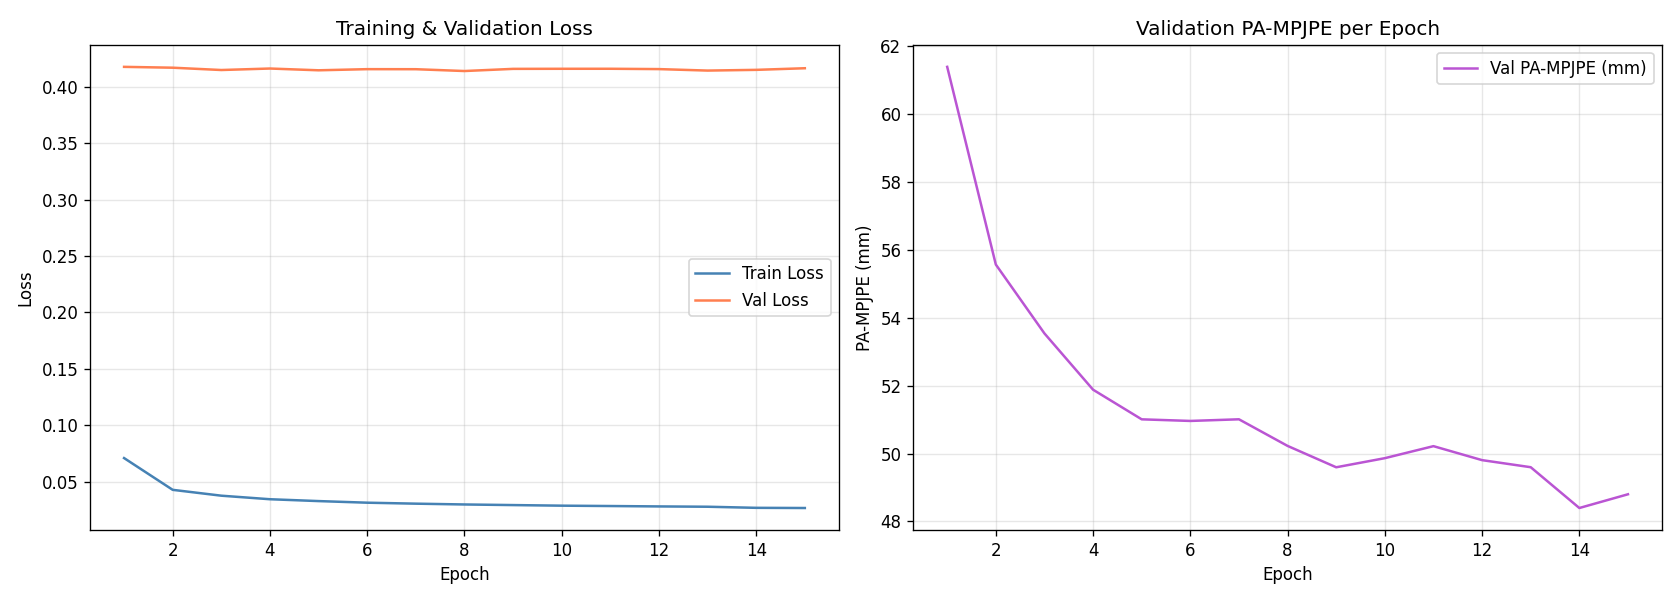

Training complete. Best PA-MPJPE: 48.40 mm


(OptimizedModule(
   (_orig_mod): Temporal3DRefinementNet(
     (expand): TemporalConv(
       (conv): Conv1d(99, 256, kernel_size=(1,), stride=(1,))
       (bn): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       (relu): ReLU(inplace=True)
       (dropout): Dropout(p=0.0, inplace=False)
     )
     (res_blocks): ModuleList(
       (0): ResidualBlock1D(
         (conv1): TemporalConv(
           (conv): Conv1d(256, 256, kernel_size=(3,), stride=(1,), padding=(1,))
           (bn): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
           (relu): ReLU(inplace=True)
           (dropout): Dropout(p=0.25, inplace=False)
         )
         (conv2): Conv1d(256, 256, kernel_size=(3,), stride=(1,), padding=(1,))
         (bn): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
         (relu): ReLU(inplace=True)
         (dropout): Dropout(p=0.25, inplace=False)
       )
       (1): ResidualBl

In [9]:
train_tcn()